In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# load xlsx file
df = pd.read_excel('count_more_trap.xlsx')
df.head()

,strain_type,data,roi_index,trapped_bugs,n_capsule
0,FO,FO_1st_round_after_60min,1,1,20
1,FO,FO_1st_round_after_60min,2,2,20
2,FO,FO_1st_round_after_60min,3,3,20
3,FO,FO_1st_round_after_60min,4,4,20
4,FO,FO_1st_round_after_60min,5,3,20


In [3]:
# separate by strain_type
df_FO = df[df['strain_type'] == 'FO']
df_WT = df[df['strain_type'] == 'WT']

In [4]:
# sum up
# for each data, count num of rows, divided by n_capsule
df_FO_sum = df_FO.groupby('data').size() / df_FO.groupby('data')['n_capsule'].mean()
df_WT_sum = df_WT.groupby('data').size() / df_WT.groupby('data')['n_capsule'].mean()

# for each data, get the n_capsule
df_FO_n_capsule = df_FO.groupby('data')['n_capsule']
df_WT_n_capsule = df_WT.groupby('data')['n_capsule']
df_FO_n_capsule = df_FO_n_capsule.mean()
df_WT_n_capsule = df_WT_n_capsule.mean()
print(df_FO_n_capsule)
print(df_WT_n_capsule)

data
FO_1st_round_after_60min      20.0
FO_1st_round_after_60min_2    16.0
FO_1st_round_after_60min_3    21.0
FO_1st_round_after_60min_4    21.0
Name: n_capsule, dtype: float64
data
WT_1st_round_after_60min_1    17.0
WT_1st_round_after_60min_2    11.0
WT_1st_round_after_60min_3    18.0
WT_1st_round_after_60min_4    14.0
Name: n_capsule, dtype: float64


Filling Percentage - Welch’s t-test
  FI vs. FII: t = -6.486, p = 9.095e-04, ***
Forward entry:
Median: 0.13
Mean+-std: 0.13+-0.06
N = 4
min n_capsule: 11.0
max n_capsule: 18.0
Backward entry:
Median: 0.53
Mean+-std: 0.54+-0.09
N = 4
min n_capsule: 16.0
max n_capsule: 21.0


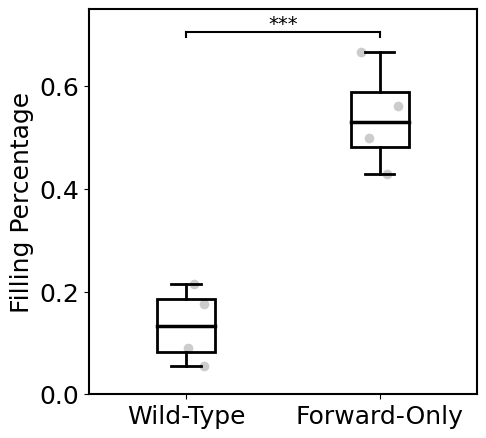

In [5]:
from scipy import stats

# Define line thickness
thickness_axis = 1.5
thickness_box = 1.5
thickness_mean = 1.5

key_parameter = 'Filling Percentage'

# Define box plot colors
# colors = ['#333333', 'dimgray', 'darkgray']
colors = ['white', 'white']

# Get the data for each group
# data_1 = df_WT[key_parameter].dropna()
# data_2 = df_FO[key_parameter].dropna()
data_1 = df_WT_sum
data_2 = df_FO_sum

# Convert to numeric arrays
data_1 = np.array(data_1, dtype=np.float64)
data_2 = np.array(data_2, dtype=np.float64)

# Sort data
data_1 = np.sort(data_1)
data_2 = np.sort(data_2)
len_FI = len(data_1)
len_FII = len(data_2)

# # Remove outliers (> k*std, < k*std)
# outlier_k = 3
# data_1 = data_1[(data_1 > np.mean(data_1) - outlier_k * np.std(data_1)) & 
#                    (data_1 < np.mean(data_1) + outlier_k * np.std(data_1))]

# data_2 = data_2[(data_2 > np.mean(data_2) - outlier_k * np.std(data_2)) & 
#                      (data_2 < np.mean(data_2) + outlier_k * np.std(data_2))]

# print('before - after removing outliers:')
# print(f'FI: {len_FI} - {len(data_1)}')
# print(f'FII: {len_FII} - {len(data_2)}')

# Perform normality test
normality = all([len(data) > 2 and stats.shapiro(data)[1] > 0.05 for data in [data_1, data_2]])

# Perform statistical test (Welch’s t-test if normal, Mann-Whitney U otherwise)
if normality:
    stat, p_value = stats.ttest_ind(data_1, data_2, equal_var=False)  # Welch's t-test
    stat_symbol = "t"
    test_name = "Welch’s t-test"
else:
    stat, p_value = stats.mannwhitneyu(data_1, data_2, alternative='two-sided')  # Mann-Whitney U test
    stat_symbol = "U"
    test_name = "Mann-Whitney U test"

# Assign significance label
def significance_label(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "n.s."

sig_label = significance_label(p_value)

# # Create box plot
# plt.figure(figsize=(5, 5))
# whis = 1
# bp = plt.boxplot([data_1, data_2], vert=True, patch_artist=True, widths=0.5, 
#                  medianprops={'color': 'black', 'linewidth': thickness_mean},
#                  boxprops=dict(linewidth=thickness_box), whiskerprops=dict(linewidth=thickness_axis),
#                  capprops=dict(linewidth=thickness_axis), whis = whis)
# # Set box colors
# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)

plt.figure(figsize=(5, 5))
palette = {
    'Wild-Type': 'white',
    'Forward-Only': 'white',
}
# Prepare DataFrame
df = pd.DataFrame({
    'value': np.concatenate([data_1, data_2]),
    'group': ['Wild-Type'] * len(data_1) + ['Forward-Only'] * len(data_2)
})

group_order = ['Wild-Type', 'Forward-Only']

# Group the data for boxplot
data_ordered = [df[df['group'] == group]['value'].values for group in group_order]

ax = plt.gca()

bp = ax.boxplot(
    data_ordered,
    positions=range(len(group_order)),
    widths=0.3,
    patch_artist=True,
    boxprops=dict(facecolor='none', edgecolor='k', linewidth=2, alpha=1),
    whiskerprops=dict(color='k', linewidth=2, alpha = 1),
    capprops=dict(color='k', linewidth=2, alpha = 1),
    medianprops=dict(color='k', linewidth=2.5, alpha=1),
    flierprops=dict(marker='o', markersize=0)
)

# Strip plot
# fix random seed for reproducibility
# np.random.seed(5)
np.random.seed(4)
# sns.stripplot(data=df, x='group', y='value', order=group_order,
#               color='black', size=4, jitter=0.15, alpha=0.3)
import seaborn as sns
sns.stripplot(data=df, x='group', y='value', order=group_order,
              color='black', size=7, jitter=0.1, alpha=0.2)



# Add significance annotation
y_max = np.nanmax([np.nanmax(data_1), np.nanmax(data_2)])
y_line = y_max * 1.06
vline_height = y_max * 0.015

plt.plot([0, 1], [y_line, y_line], color='black', linewidth=thickness_axis)  # Short horizontal line
plt.plot([0, 0], [y_line, y_line - vline_height], color='black')  # Vertical line (left)
plt.plot([1, 1], [y_line, y_line - vline_height], color='black')  # Vertical line (right)
plt.text(0.5, y_line - y_max * 0.005, sig_label, ha='center', va='bottom', fontsize=12, color='black')

# # add median value on top of box
# plt.text(1, np.nanmedian(data_1), f'{np.nanmedian(data_1):.2f}', ha='center', va='bottom', fontsize=12, color='black')
# plt.text(2, np.nanmedian(data_2), f'{np.nanmedian(data_2):.2f}', ha='center', va='bottom', fontsize=12, color='black')

# Set labels
plt.xticks([0, 1], ['Wild-Type', 'Forward-Only'])
plt.ylabel('Filling Percentage')
# ylim
plt.ylim(0, 0.75)
plt.xlim(-0.5, 1.5)
plt.xlabel('')

# Print statistical results
print(f'{key_parameter} - {test_name}')
print(f'  FI vs. FII: {stat_symbol} = {stat:.3f}, p = {p_value:.3e}, {sig_label}')

# plt.figure(figsize=(6,5.5))

# ---Parameters---
ax = plt.gca()
# Font sizes
ax.tick_params(axis='both', which='major', labelsize=18)  # Tick label size

# Get the current content of the labels and title
xlabel = ax.get_xlabel()
ylabel = ax.get_ylabel()
title = ax.get_title()

# Set the font sizes without changing the content
ax.set_xlabel(xlabel, fontsize=18)  # X-axis label size
ax.set_ylabel(ylabel, fontsize=18)  # Y-axis label size
ax.set_title(title, fontsize=18)  # Title size

# Set legend size (if you have a legend)
legend = ax.get_legend()
if legend:
    for label in legend.get_texts():
        label.set_fontsize(14)

# Set text size for any additional annotations
for text in ax.texts:
    text.set_fontsize(14)

# Make axes thicker
for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)

# Reduce num of ticks
ax.locator_params(axis='y', nbins=6)
ax.locator_params(axis='x', nbins=6)

# increase x tick label size
plt.gca().get_xticklabels()
plt.setp(ax.get_xticklabels(), fontsize=18)

# print median and mean+-std values
print('Forward entry:')
print(f'Median: {np.median(data_1):.2f}')
print(f'Mean+-std: {np.mean(data_1):.2f}+-{np.std(data_1):.2f}')
print(f'N = {len(data_1)}')
# print num of capsules
print(f'min n_capsule: {df_WT_n_capsule.min()}')
print(f'max n_capsule: {df_WT_n_capsule.max()}')
print('Backward entry:')
print(f'Median: {np.median(data_2):.2f}')
print(f'Mean+-std: {np.mean(data_2):.2f}+-{np.std(data_2):.2f}')
print(f'N = {len(data_2)}')
print(f'min n_capsule: {df_FO_n_capsule.min()}')
print(f'max n_capsule: {df_FO_n_capsule.max()}')

# Save figure as PNG (optional), transparent background, tight bounding box
# plt.savefig('Filling Percentage-box plot.png', format='png', dpi=900, transparent=True, bbox_inches='tight')
